In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve
import matplotlib.pyplot as plt

In [2]:
x_test = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/x_test.csv')
y_test = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/y_test.csv')

train_dtypes = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/train_dtypes.pkl')

In [3]:
# models
rf_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_rf.pkl')
xgb_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_xg.pkl')
lgb_model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_lgb.pkl')

/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [16:30:42] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [16:30:42] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/home/prince/anaconda3/lib/python3.13/pickle.py:1760: UserWarning: [16:30:42] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


## Confidence Score model

In [ ]:
for col in x_test.columns:
    x_test[col] = x_test[col].astype(train_dtypes[col])

rf_proba   = rf_model.predict_proba(x_test)[:,1]
xgb_proba  = xgb_model.predict_proba(x_test)[:,1]
lgb_proba = lgb_model.predict_proba(x_test)[:,1]

# Confidence score calculation
scores_matrix = np.array([rf_proba, xgb_proba, lgb_proba])

avg_score  = np.mean(scores_matrix, axis=0)
std_score  = np.std(scores_matrix, axis=0)
conf_score = avg_score * (1 - std_score)

/home/prince/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
y_pred_conf = (conf_score >= 0.5).astype(int)

y_test_flat = y_test.values.ravel()
# Classification report
print("Confidence Score Model")
print(f"Fraud Mean:     {conf_score[y_test_flat == 1].mean():.4f}")
print(f"Non-Fraud Mean: {conf_score[y_test_flat == 0].mean():.4f}")
print(f"Gap: {conf_score[y_test_flat == 1].mean() - conf_score[y_test_flat == 0].mean():.4f}")
print(classification_report(y_test, y_pred_conf))

Confidence Score Model
Fraud Mean:     0.5617
Non-Fraud Mean: 0.4171
Gap: 0.1446
              precision    recall  f1-score   support

           0       0.98      0.83      0.90    113659
           1       0.10      0.53      0.17      4124

    accuracy                           0.82    117783
   macro avg       0.54      0.68      0.53    117783
weighted avg       0.95      0.82      0.87    117783



In [6]:
conf_score = np.mean(scores_matrix, axis=0)
y_pred_conf = (conf_score >= 0.5).astype(int)

print("Confidence Score Model")
print(f"Fraud Mean:     {conf_score[y_test_flat == 1].mean():.4f}")
print(f"Non-Fraud Mean: {conf_score[y_test_flat == 0].mean():.4f}")
print(f"Gap: {conf_score[y_test_flat == 1].mean() - conf_score[y_test_flat == 0].mean():.4f}")
print(classification_report(y_test, y_pred_conf))

Confidence Score Model
Fraud Mean:     0.5904
Non-Fraud Mean: 0.4347
Gap: 0.1557
              precision    recall  f1-score   support

           0       0.98      0.76      0.86    113659
           1       0.08      0.58      0.14      4124

    accuracy                           0.75    117783
   macro avg       0.53      0.67      0.50    117783
weighted avg       0.95      0.75      0.83    117783



In [7]:
comparison_df = pd.DataFrame({
    'actual'          : y_test_flat,
    'rf_score'        : (rf_proba * 100).round(2),
    'xgb_score'       : (xgb_proba * 100).round(2),
    'lgb_score'      : (lgb_proba * 100).round(2),
    'confidence_score': (conf_score * 100).round(2),
    'predicted_fraud' : y_pred_conf
})

# Separate fraud and non fraud
print("=== ACTUAL FRAUD TRANSACTIONS ===")
print(comparison_df[comparison_df['actual'] == 1].head(10).to_string())

print("\n=== ACTUAL NON-FRAUD TRANSACTIONS ===")
print(comparison_df[comparison_df['actual'] == 0].head(10).to_string())

=== ACTUAL FRAUD TRANSACTIONS ===
     actual  rf_score  xgb_score  lgb_score  confidence_score  predicted_fraud
4         1     85.75  92.800003      92.16             90.24                1
11        1     75.32  93.459999      87.95             85.58                1
23        1     74.68  87.330002      86.81             82.94                1
51        1     41.66  36.919998      42.86             40.48                0
79        1     44.67  53.380001      50.46             49.50                0
95        1     57.16  76.150002      72.50             68.60                1
99        1     61.50  71.629997      71.59             68.24                1
101       1     55.19  74.300003      69.86             66.45                1
120       1     44.87  38.930000      40.13             41.31                0
163       1     53.93  44.570000      44.69             47.73                0

=== ACTUAL NON-FRAUD TRANSACTIONS ===
    actual  rf_score  xgb_score  lgb_score  confidence_sco

## PR graphs

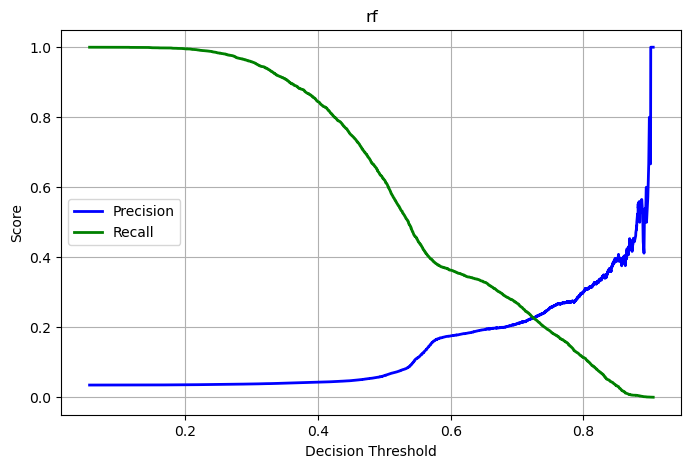

In [8]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('rf')
plt.legend()
plt.grid(True)
plt.show()

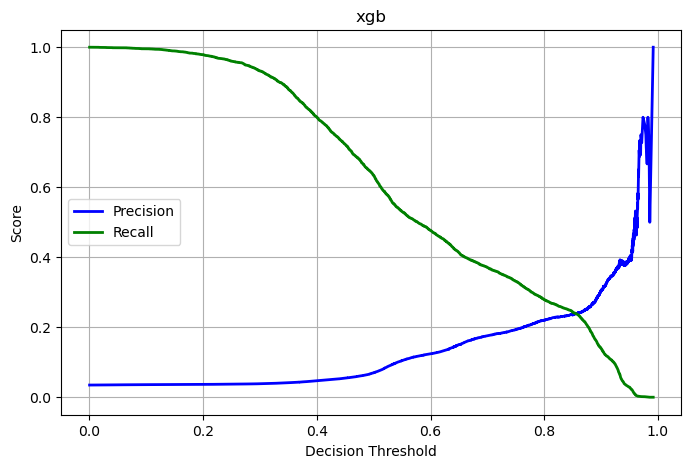

In [9]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('xgb')
plt.legend()
plt.grid(True)
plt.show()

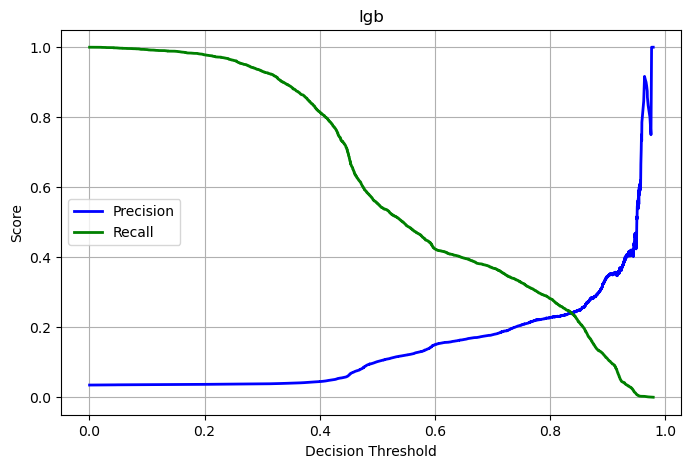

In [10]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, lgb_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('lgb')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#  finalized confidence threshold

rf_pred_spec  = (rf_proba  >= 0.82).astype(int)  # keep same ✅
xgb_pred_spec = (xgb_proba >= 0.68).astype(int)  # slight up from 0.65
lgb_pred_spec = (lgb_proba >= 0.58).astype(int)  # back up from 0.45

print("=== RF - High Precision ===")
print(classification_report(y_test_flat, rf_pred_spec))

print("=== XGB - Balanced ===")
print(classification_report(y_test_flat, xgb_pred_spec))

print("=== LGBM - High Recall ===")
print(classification_report(y_test_flat, lgb_pred_spec))


=== RF - High Precision ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    113659
           1       0.33      0.08      0.13      4124

    accuracy                           0.96    117783
   macro avg       0.65      0.54      0.55    117783
weighted avg       0.95      0.96      0.95    117783

=== XGB - Balanced ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95    113659
           1       0.17      0.39      0.23      4124

    accuracy                           0.91    117783
   macro avg       0.57      0.66      0.59    117783
weighted avg       0.95      0.91      0.93    117783

=== LGBM - High Recall ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93    113659
           1       0.13      0.46      0.21      4124

    accuracy                           0.88    117783
   macro avg       0.56      0.67      0.57    117

In [21]:
# Majority voting — 2 out of 3 = fraud
votes = rf_pred_spec + xgb_pred_spec + lgb_pred_spec
majority_pred = (votes >= 2).astype(int)

# Full comparison table
comparison = pd.DataFrame({
    'actual'          : y_test_flat,
    'rf_precision'    : rf_pred_spec,
    'xgb_balanced'    : xgb_pred_spec,
    'lgbm_recall'     : lgb_pred_spec,
    'majority_vote'   : majority_pred,
    'votes'           : votes
})

print("=== MAJORITY VOTING - 2/3 Agreement ===")
print(classification_report(y_test_flat, majority_pred))

print("\n=== ACTUAL FRAUD TRANSACTIONS ===")
print(comparison[comparison['actual'] == 1].head(15).to_string())

print("\n=== ACTUAL NON-FRAUD TRANSACTIONS ===")
print(comparison[comparison['actual'] == 0].head(15).to_string())

=== MAJORITY VOTING - 2/3 Agreement ===
              precision    recall  f1-score   support

           0       0.98      0.93      0.95    113659
           1       0.17      0.38      0.23      4124

    accuracy                           0.91    117783
   macro avg       0.57      0.66      0.59    117783
weighted avg       0.95      0.91      0.93    117783


=== ACTUAL FRAUD TRANSACTIONS ===
     actual  rf_precision  xgb_balanced  lgbm_recall  majority_vote  votes
4         1             1             1            1              1      3
11        1             0             1            1              1      2
23        1             0             1            1              1      2
51        1             0             0            0              0      0
79        1             0             0            0              0      0
95        1             0             1            1              1      2
99        1             0             1            1              1      

In [ ]:
thresholds = {
    'rf'  : 0.82,
    'xgb' : 0.68,
    'lgb': 0.58,
}
# joblib.dump(thresholds, 'confidence_thresholds.pkl')

['confidence_thresholds.pkl']

In [35]:
#  finalized confidence threshold

rf_pred_spec  = (rf_proba  >= 0.5).astype(int)  # keep same ✅
xgb_pred_spec = (xgb_proba >= 0.5).astype(int)  # slight up from 0.65
lgb_pred_spec = (lgb_proba >= 0.5).astype(int)  # back up from 0.45

print("=== RF ===")
print(classification_report(y_test_flat, rf_pred_spec))

print("=== XGB ===")
print(classification_report(y_test_flat, xgb_pred_spec))

print("=== LGBM ===")
print(classification_report(y_test_flat, lgb_pred_spec))

=== RF ===
              precision    recall  f1-score   support

           0       0.98      0.66      0.79    113659
           1       0.06      0.62      0.11      4124

    accuracy                           0.66    117783
   macro avg       0.52      0.64      0.45    117783
weighted avg       0.95      0.66      0.77    117783

=== XGB ===
              precision    recall  f1-score   support

           0       0.98      0.70      0.81    113659
           1       0.07      0.63      0.13      4124

    accuracy                           0.69    117783
   macro avg       0.53      0.66      0.47    117783
weighted avg       0.95      0.69      0.79    117783

=== LGBM ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89    113659
           1       0.10      0.55      0.17      4124

    accuracy                           0.81    117783
   macro avg       0.54      0.69      0.53    117783
weighted avg       0.95      0.81     